# Itau Quant Challenge 2025 - Pipeline End-to-End

Este notebook executa o processo completo do repositorio, explicando cada etapa e salvando artefatos em `reports/`.

Etapas:
- Carregar configuracao e dados
- Rodar backtest base e exibir KPIs
- Walk-forward validation
- Heatmaps de sensibilidade de parametros
- Stress de custos de transacao
- Capacity curve
- (Opcional) PDF consolidado do relatorio


In [1]:
import features, importlib, sys
print("features from:", features.__file__)
import features.tda as tda, features.factors as fac
print("has get_alphas_from_cfg?", hasattr(fac, "get_alphas_from_cfg"))
print("TFIParams.from_config?", hasattr(tda.TFIParams, "from_config"))
print(sys.path[:3])


features from: D:\GitHub Dic\itau-quant-challenge-2025\src\features\__init__.py
has get_alphas_from_cfg? True
TFIParams.from_config? True
['D:\\GitHub Dic\\itau-quant-challenge-2025\\src', 'C:\\Users\\felip\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\felip\\AppData\\Local\\Programs\\Python\\Python312\\DLLs']


In [2]:
# Setup
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

import os; os.environ["REGIME_GAIN"] = "2"
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'src').exists(), 'Execute a partir do repo root ou da pasta notebooks/'
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
%matplotlib inline

REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print('Repo root:', ROOT)
print('Reports dir:', REPORTS_DIR)

Repo root: d:\GitHub Dic\itau-quant-challenge-2025
Reports dir: d:\GitHub Dic\itau-quant-challenge-2025\reports


## Configuracao
Carrega o YAML de configuracao base do projeto.

In [3]:
from dataio.config import load_config

CONFIG_PATH = ROOT / 'configs' / 'base.yaml'
cfg = load_config(str(CONFIG_PATH))
print('Config carregada:', CONFIG_PATH)
print('Datas:', cfg.get('dates'))
cfg

Config carregada: d:\GitHub Dic\itau-quant-challenge-2025\configs\base.yaml
Datas: {'start': datetime.date(2017, 9, 4), 'end': datetime.date(2025, 10, 6)}


{'portfolio': {'method': 'hrp',
  'periphery_bias_lambda': 0.0,
  'expected_returns': {'enabled': True,
   'max_tilt': 0.03,
   'min_signal_z': 0.0,
   'regime_gate': 0.0,
   'risk_aversion': 2.5,
   'long_only': True}},
 'data': {'source': 'local_csv'},
 'paths': {'data': './data',
  'reports': './reports',
  'artifacts': './artifacts'},
 'seeds': 42,
 'dates': {'start': datetime.date(2017, 9, 4),
  'end': datetime.date(2025, 10, 6)},
 'tda': {'delay': 1,
  'dim': 2,
  'n_cubes': 2,
  'overlap': 0.2,
  'epsilon': None,
  'min_samples': 4,
  'window': 168,
  'eps_quantile': 0.15,
  'smooth_span': 10,
  'n_jobs': -1},
 'tda_ph': {'enabled': True,
  'window': 105,
  'homology_dim': 1,
  'norm': 'l2',
  'smooth_span': 15,
  'zscore_lookback': 250,
  'alert_sigma': 1.0,
  'riskoff_sigma': 2.0},
 'mapper': {'enabled': True,
  'lens': 'pca_umap',
  'n_cubes': 9,
  'overlap': 0.5,
  'eps_quantile': 0.15,
  'min_cluster_size': 4,
  'epsilon_adaptive': True},
 'factors': {'alphas': ['momentum',

## Dados
Carrega o painel de mercado. Se o `get_panel` falhar, cai para dados sinteticos. Exibe um preview e o intervalo de datas.

In [4]:
from main import _load_panel as _load_panel

panel = _load_panel(cfg)
date_level = 'date' if 'date' in panel.index.names else panel.index.names[0]
print('Panel shape:', panel.shape)
print('Date range:', panel.index.get_level_values(date_level).min(), '->', panel.index.get_level_values(date_level).max())
panel.sort_index().head()

Panel shape: (137210, 2)
Date range: 2017-09-04 00:00:00 -> 2025-10-06 00:00:00


close       volume
date       asset                    
2017-09-04 ABEV3  19.73  241157365.0
           BBAS3  31.84  131657322.0
           BBDC3  32.50   21465083.0
           BBDC4  34.25  144471903.0
           BBSE3  27.93   62636989.0

## Backtest Base
Executa o backtest principal, plota a equity e salva artefatos em `reports/`.

In [ ]:
from copy import deepcopy
from backtest.engine import run_backtest
from reports import plot_equity_curves, table_kpis

bt = run_backtest(cfg, panel=panel)
equity = bt['equity_curve']
returns = equity.pct_change().dropna()

hrp_cfg = deepcopy(cfg)
hrp_portfolio = hrp_cfg.setdefault('portfolio', {})
hrp_portfolio['method'] = 'hrp_only'
hrp_portfolio.setdefault('hrp_only_regime_value', 0.5)

tda_cfg = deepcopy(cfg)
tda_cfg.setdefault('portfolio', {})['method'] = 'tda_only'

bt_hrp = run_backtest(hrp_cfg, panel=panel)
equity_hrp = bt_hrp['equity_curve']
returns_hrp = equity_hrp.pct_change().dropna()

bt_tda = run_backtest(tda_cfg, panel=panel)
equity_tda = bt_tda['equity_curve']
returns_tda = equity_tda.pct_change().dropna()

ibov_path = (ROOT / 'data' / 'benchmark' / 'ibovespa_index_b3.csv').resolve()
ibov_prices = (
    pd.read_csv(ibov_path, parse_dates=['date'], index_col='date')['close']
    .sort_index()
)
ibov_prices_aligned = ibov_prices.reindex(equity.index).ffill()
if ibov_prices_aligned.isna().all():
    raise ValueError('Ibovespa benchmark does not overlap with backtest dates.')
ibov_equity = (ibov_prices_aligned / ibov_prices_aligned.iloc[0]).rename('Ibovespa')
ibov_returns = ibov_equity.pct_change().fillna(0.0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(equity.index, equity.values, label='Strategy')
ax.plot(equity_hrp.index, equity_hrp.values, label='HRP Only', linestyle='--')
ax.plot(equity_tda.index, equity_tda.values, label='TDA Only', linestyle='-.')
ax.plot(ibov_equity.index, ibov_equity.values, label='Ibovespa', linestyle=':')
ax.set_title('Equity Curve Comparison - Backtest')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

kpi = table_kpis({
    'Strategy': {
        'equity_curve': equity,
        'returns': returns,
        'weights': bt.get('daily_positions')
    },
    'HRP Only': {
        'equity_curve': equity_hrp,
        'returns': returns_hrp,
        'weights': bt_hrp.get('daily_positions')
    },
    'TDA Only': {
        'equity_curve': equity_tda,
        'returns': returns_tda,
        'weights': bt_tda.get('daily_positions')
    },
    'Ibovespa': {
        'equity_curve': ibov_equity,
        'returns': ibov_returns,
        'weights': None
    }
})
display(Markdown('**KPIs - Backtest (Strategy vs HRP Only vs TDA Only vs Ibovespa)**'))
display(kpi)

comparison_png = plot_equity_curves(
    {
        'Strategy': equity,
        'HRP Only': equity_hrp,
        'TDA Only': equity_tda,
        'Ibovespa': ibov_equity,
    },
    filename='equity_curve_comparison.png'
)
print('Comparacao salva em:', comparison_png)


In [ ]:
# import numpy as np, pandas as pd, matplotlib.pyplot as plt
# from pathlib import Path

# try:
#     ibov_series = ibov_prices.copy()
# except NameError:
#     project_root = Path.cwd().resolve().parent
#     ibov_path = project_root / 'data' / 'benchmark' / 'ibovespa_index_b3.csv'
#     ibov_series = (
#         pd.read_csv(ibov_path, parse_dates=['date'], index_col='date')['close']
#         .sort_index()
#     )

# idx = equity.index.intersection(ibov_series.index)
# if idx.empty:
#     raise ValueError('Ibovespa series does not overlap with strategy equity dates.')

# eq = equity.loc[idx].ffill()
# ib_prices = ibov_series.loc[idx].ffill()

# try:
#     ib = ibov_equity.reindex(idx).ffill()
# except NameError:
#     ib = (ib_prices / ib_prices.iloc[0]).rename('Ibovespa')

# r_s = eq.pct_change().fillna(0.0)
# try:
#     r_b = ibov_returns.reindex(idx).fillna(0.0)
# except NameError:
#     r_b = ib.pct_change().fillna(0.0)
# r_ex = r_s - r_b

# ann = 252
# te = r_ex.std(ddof=0) * np.sqrt(ann)
# ir = (r_ex.mean() / r_ex.std(ddof=0)) * np.sqrt(ann) if r_ex.std(ddof=0) > 0 else np.nan
# beta = (r_s.cov(r_b) / r_b.var()) if r_b.var() > 0 else np.nan
# alpha_ann = (r_s.mean() - beta * r_b.mean()) * ann if beta == beta else np.nan

# cagr_s = (eq.iloc[-1] / eq.iloc[0]) ** (ann / len(r_s)) - 1
# cagr_b = (ib.iloc[-1] / ib.iloc[0]) ** (ann / len(r_b)) - 1
# dd_s = (eq / eq.cummax() - 1.0).min()
# dd_b = (ib / ib.cummax() - 1.0).min()
# hit_m = (r_s.resample('M').sum() > r_b.resample('M').sum()).mean()

# summary = pd.Series({
#     'CAGR_Strategy': cagr_s,
#     'CAGR_Ibov': cagr_b,
#     'Excess_CAGR': cagr_s - cagr_b,
#     'Alpha_ann': alpha_ann,
#     'Beta': beta,
#     'TrackingError': te,
#     'InformationRatio': ir,
#     'MaxDD_Strategy': dd_s,
#     'MaxDD_Ibov': dd_b,
#     'MonthlyHitRate': hit_m,
# }).to_frame('value')
# display(summary)

# active_curve = (1.0 + r_ex).cumprod()
# ax = active_curve.plot(figsize=(10, 4), color='tab:purple', label='Active return (S - I)')
# ax.axhline(1.0, color='black', lw=0.8, alpha=0.4)
# ax.set_title('Cumulative Active Return vs Ibovespa')
# ax.grid(True, alpha=0.3)
# ax.legend()
# plt.tight_layout()
# plt.show()


## Walk-Forward Validation
Executa validacao walk-forward (2 anos in-sample / 6 meses out-of-sample). Mostra equity e KPIs agregados.

Kill switch triggered on 2018-02-14 (vol=0.1650)
Kill switch triggered on 2018-09-21 (vol=0.1604)
Kill switch triggered on 2018-11-08 (vol=0.1618)
Kill switch triggered on 2019-01-09 (vol=0.1632)
Kill switch triggered on 2019-06-06 (vol=0.1603)
Kill switch triggered on 2019-10-15 (vol=0.1602)
Kill switch triggered on 2020-01-02 (vol=0.2239)
Kill switch triggered on 2020-09-03 (vol=0.1640)
Kill switch triggered on 2018-10-09 (vol=0.1604)
Kill switch triggered on 2019-03-27 (vol=0.1663)
Kill switch triggered on 2019-10-11 (vol=0.1640)
Kill switch triggered on 2019-11-12 (vol=0.1637)
Kill switch triggered on 2020-01-02 (vol=0.2144)
Kill switch triggered on 2020-05-04 (vol=1.2628)
Kill switch triggered on 2021-01-04 (vol=0.1863)
Kill switch triggered on 2021-07-12 (vol=0.1621)
Kill switch triggered on 2019-07-03 (vol=0.1644)
Kill switch triggered on 2020-01-02 (vol=0.2324)
Kill switch triggered on 2020-05-04 (vol=0.7279)
Kill switch triggered on 2020-10-08 (vol=0.1682)
Kill switch triggere

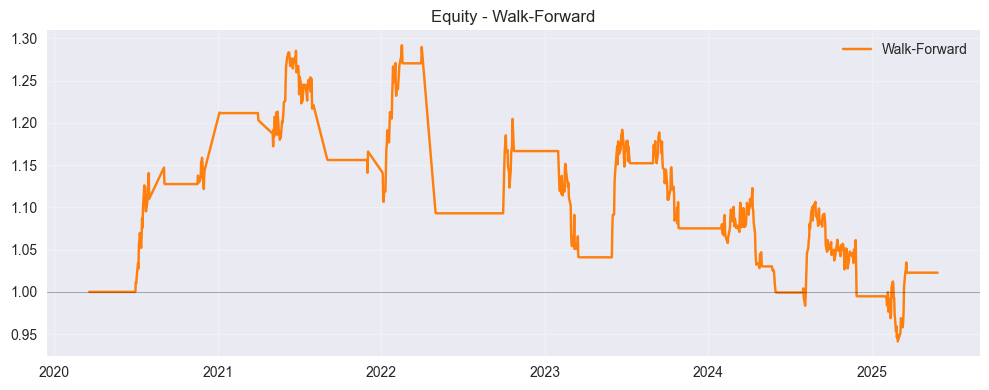

**KPIs - Walk-Forward**

,Valor
CAGR,0.005001
Sharpe,0.109961
Sortino,0.080108
Vol,0.149356
MaxDD,-0.271264
AvgTimeUnderWater,19.857143
MaxTimeUnderWater,119.000000
Calmar,0.018437
HitRate,0.517937
Turnover,0.014086


**Janelas Walk-Forward (amostra)**

,is_start,is_end,oos_start,oos_end,kpis,config
0,2017-09-04,2020-03-18,2020-03-19,2020-11-16,"{'final_equity': 1.3114867320597405, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '..."
1,2018-05-14,2020-11-16,2020-11-17,2021-07-16,"{'final_equity': 2.1140417913489706, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '..."
2,2018-12-14,2021-07-16,2021-07-19,2022-03-18,"{'final_equity': 1.2948669770551418, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '..."
3,2019-07-23,2022-03-18,2022-03-21,2022-11-16,"{'final_equity': 1.1582003015087956, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '..."
4,2020-03-19,2022-11-16,2022-11-17,2023-05-19,"{'final_equity': 0.8239314182950426, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '..."


In [ ]:
from validation import run_walk_forward

wf = run_walk_forward(cfg, panel)
walk_equity = wf['equity_curve']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(walk_equity.index, walk_equity.values, color='#ff7f0e', label='Walk-Forward')
ax.axhline(1.0, color='black', linewidth=0.8, alpha=0.3)
ax.set_title('Equity - Walk-Forward')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown('**KPIs - Walk-Forward**'))
display(pd.DataFrame(wf['kpis'], index=['Valor']).T)

windows_df = pd.DataFrame(wf['windows'])
display(Markdown('**Janelas Walk-Forward (amostra)**'))
display(windows_df.head())

### Funcoes auxiliares para grids customizados
Utilidades genericas para montar grids 2D de parametros (kill switch, caps do HRP, etc.), extraindo metricas financeiras e salvando os artefatos em `reports/parameter_sweeps`.

In [ ]:

from copy import deepcopy
from pathlib import Path

reports_dir = REPORTS_DIR / "parameter_sweeps"
reports_dir.mkdir(parents=True, exist_ok=True)

def _set_nested(cfg_dict, dotted_key, value):
    parts = dotted_key.split('.')
    node = cfg_dict
    for key in parts[:-1]:
        if key not in node or not isinstance(node[key], dict):
            node[key] = {}
        node = node[key]
    node[parts[-1]] = value

def _extract_metrics(kpis):
    if not isinstance(kpis, dict):
        return {"cagr": np.nan, "sharpe": np.nan, "vol": np.nan, "max_drawdown": np.nan, "calmar": np.nan}
    cagr = kpis.get('CAGR')
    if cagr is None:
        cagr = kpis.get('annual_return')
    sharpe_val = kpis.get('Sharpe')
    if sharpe_val is None:
        sharpe_val = kpis.get('sharpe')
    vol = kpis.get('Vol')
    if vol is None:
        vol = kpis.get('annual_vol')
    maxdd = kpis.get('MaxDD')
    if maxdd is None:
        maxdd = kpis.get('max_drawdown')
    calmar = np.nan
    if maxdd not in (None, 0) and np.isfinite(maxdd) and cagr is not None and np.isfinite(cagr):
        denom = abs(maxdd)
        calmar = cagr / denom if denom > 0 else np.nan
    return {
        'cagr': cagr,
        'sharpe': sharpe_val,
        'vol': vol,
        'max_drawdown': maxdd,
        'calmar': calmar,
    }

def run_two_param_heatmaps(cfg_base, panel_data, grid, report_prefix, plot_metrics=('sharpe', 'max_drawdown')):
    if len(grid) != 2:
        raise ValueError('Grid precisa ter exatamente dois parametros para heatmap.')
    axes = list(grid.keys())
    axis_values = [list(grid[axes[0]]), list(grid[axes[1]])]
    metric_surfaces = {metric: np.full((len(axis_values[0]), len(axis_values[1])), np.nan) for metric in plot_metrics}
    records = []
    for i, val_x in enumerate(axis_values[0]):
        for j, val_y in enumerate(axis_values[1]):
            cfg_run = deepcopy(cfg_base)
            _set_nested(cfg_run, axes[0], val_x)
            _set_nested(cfg_run, axes[1], val_y)
            print(f" - Walk-forward {report_prefix} | {axes[0]}={val_x}, {axes[1]}={val_y}")
            result = run_walk_forward(cfg_run, panel=panel_data)
            metrics = _extract_metrics(result.get('kpis', {}))
            record = {axes[0]: val_x, axes[1]: val_y, **metrics}
            records.append(record)
            for metric in plot_metrics:
                metric_surfaces[metric][i, j] = metrics.get(metric)
    results_df = pd.DataFrame(records)
    csv_path = reports_dir / f"{report_prefix}_results.csv"
    results_df.to_csv(csv_path, index=False)
    print(f'Resultados salvos em {csv_path}')
    heatmap_paths = {}
    for metric, surface in metric_surfaces.items():
        fig, ax = plt.subplots(figsize=(7, 5))
        im = ax.imshow(surface, origin='lower', aspect='auto', cmap='viridis')
        ax.set_xticks(range(len(axis_values[1])))
        ax.set_xticklabels([str(v) for v in axis_values[1]])
        ax.set_yticks(range(len(axis_values[0])))
        ax.set_yticklabels([str(v) for v in axis_values[0]])
        ax.set_xlabel(axes[1])
        ax.set_ylabel(axes[0])
        ax.set_title(f"{metric.title()} - {report_prefix}")
        fig.colorbar(im, ax=ax)
        fig.tight_layout()
        out_path = reports_dir / f"{report_prefix}_{metric}_heatmap.png"
        fig.savefig(out_path, dpi=150)
        plt.close(fig)
        heatmap_paths[metric] = out_path
    return results_df, heatmap_paths


## TDA - Heatmaps de Sensibilidade
Explora combinacoes dos hiperparametros de `tda_ph` e `mapper`. Cada grid roda o backtest com os novos parametros e renderiza as figuras diretamente aqui para comparacao rapida.

**Grid tda_ph.window vs tda_ph.smooth_span** - parametros ['tda_ph.window', 'tda_ph.smooth_span']

 - Backtest tda_tda_ph-window_vs_tda_ph-smooth_span | tda_ph.window=98, tda_ph.smooth_span=5


Kill switch triggered on 2018-02-14 (vol=0.1647)
Kill switch triggered on 2018-09-03 (vol=0.1642)
Kill switch triggered on 2018-11-27 (vol=0.1644)
Kill switch triggered on 2019-03-27 (vol=0.1673)
Kill switch triggered on 2019-09-02 (vol=0.2221)
Kill switch triggered on 2020-01-02 (vol=0.2538)
Kill switch triggered on 2020-05-04 (vol=0.7605)
Kill switch triggered on 2020-10-08 (vol=0.1789)
Kill switch triggered on 2021-03-18 (vol=0.1617)
Kill switch triggered on 2021-09-08 (vol=0.1701)
Kill switch triggered on 2022-02-03 (vol=0.1600)
Kill switch triggered on 2022-05-02 (mdd=-0.1617,vol=0.3462)
Kill switch triggered on 2022-09-02 (vol=0.1627)
Kill switch triggered on 2023-03-09 (vol=0.1673)
Kill switch triggered on 2023-07-21 (vol=0.1611)
Kill switch triggered on 2023-10-26 (vol=0.1665)
Kill switch triggered on 2024-04-30 (vol=0.1602)
Kill switch triggered on 2024-12-11 (vol=0.1633)
Kill switch triggered on 2025-03-31 (vol=0.1623)


 - Backtest tda_tda_ph-window_vs_tda_ph-smooth_span | tda_ph.window=98, tda_ph.smooth_span=10


Kill switch triggered on 2018-02-14 (vol=0.1647)
Kill switch triggered on 2018-09-03 (vol=0.1642)
Kill switch triggered on 2018-11-27 (vol=0.1644)
Kill switch triggered on 2019-03-27 (vol=0.1673)
Kill switch triggered on 2019-09-02 (vol=0.2221)
Kill switch triggered on 2020-01-02 (vol=0.2538)
Kill switch triggered on 2020-05-04 (vol=0.7605)
Kill switch triggered on 2020-10-08 (vol=0.1789)
Kill switch triggered on 2021-03-18 (vol=0.1617)
Kill switch triggered on 2021-09-08 (vol=0.1701)
Kill switch triggered on 2022-02-03 (vol=0.1600)
Kill switch triggered on 2022-05-02 (mdd=-0.1617,vol=0.3462)
Kill switch triggered on 2022-09-02 (vol=0.1627)
Kill switch triggered on 2023-03-09 (vol=0.1673)
Kill switch triggered on 2023-07-21 (vol=0.1611)
Kill switch triggered on 2023-10-26 (vol=0.1665)
Kill switch triggered on 2024-04-30 (vol=0.1602)
Kill switch triggered on 2024-12-11 (vol=0.1633)
Kill switch triggered on 2025-04-04 (vol=0.1707)


...

 - Backtest tda_tda_ph-window_vs_tda_ph-smooth_span | tda_ph.window=112, tda_ph.smooth_span=15


Kill switch triggered on 2018-02-14 (vol=0.1647)
Kill switch triggered on 2018-09-03 (vol=0.1642)
Kill switch triggered on 2018-11-27 (vol=0.1644)
Kill switch triggered on 2019-03-27 (vol=0.1673)
Kill switch triggered on 2019-09-02 (vol=0.2221)
Kill switch triggered on 2020-01-02 (vol=0.2538)
Kill switch triggered on 2020-05-04 (vol=0.7605)
Kill switch triggered on 2020-09-28 (vol=0.1655)
Kill switch triggered on 2021-02-23 (vol=0.1631)
Kill switch triggered on 2021-06-02 (vol=0.1601)
Kill switch triggered on 2021-09-02 (vol=0.1632)
Kill switch triggered on 2021-10-01 (vol=0.1650)
Kill switch triggered on 2021-11-23 (vol=0.1604)
Kill switch triggered on 2022-03-09 (vol=0.1648)
Kill switch triggered on 2022-05-02 (mdd=-0.1661,vol=0.3506)
Kill switch triggered on 2022-09-02 (vol=0.1852)
Kill switch triggered on 2023-03-09 (vol=0.1708)
Kill switch triggered on 2023-07-21 (vol=0.1611)
Kill switch triggered on 2023-10-26 (vol=0.1666)
Kill switch triggered on 2024-04-30 (vol=0.1602)
Kill swi

Resultados salvos em d:\GitHub Dic\itau-quant-challenge-2025\reports\parameter_sweeps\tda_tda_ph-window_vs_tda_ph-smooth_span_results.csv


,tda_ph.window,tda_ph.smooth_span,cagr,sharpe,vol,max_drawdown,calmar
5,105,15,0.091184,0.453280,0.201165,-0.183517,0.496869
4,105,10,0.056000,0.277248,0.201986,-0.306958,0.182436
3,105,5,0.055957,0.269840,0.207373,-0.192427,0.290798
2,98,15,0.052971,0.253611,0.208867,-0.209321,0.253062
1,98,10,0.052663,0.252095,0.208902,-0.209321,0.251590


Sharpe heatmap: `d:\GitHub Dic\itau-quant-challenge-2025\reports\parameter_sweeps\tda_tda_ph-window_vs_tda_ph-smooth_span_sharpe_heatmap.png`

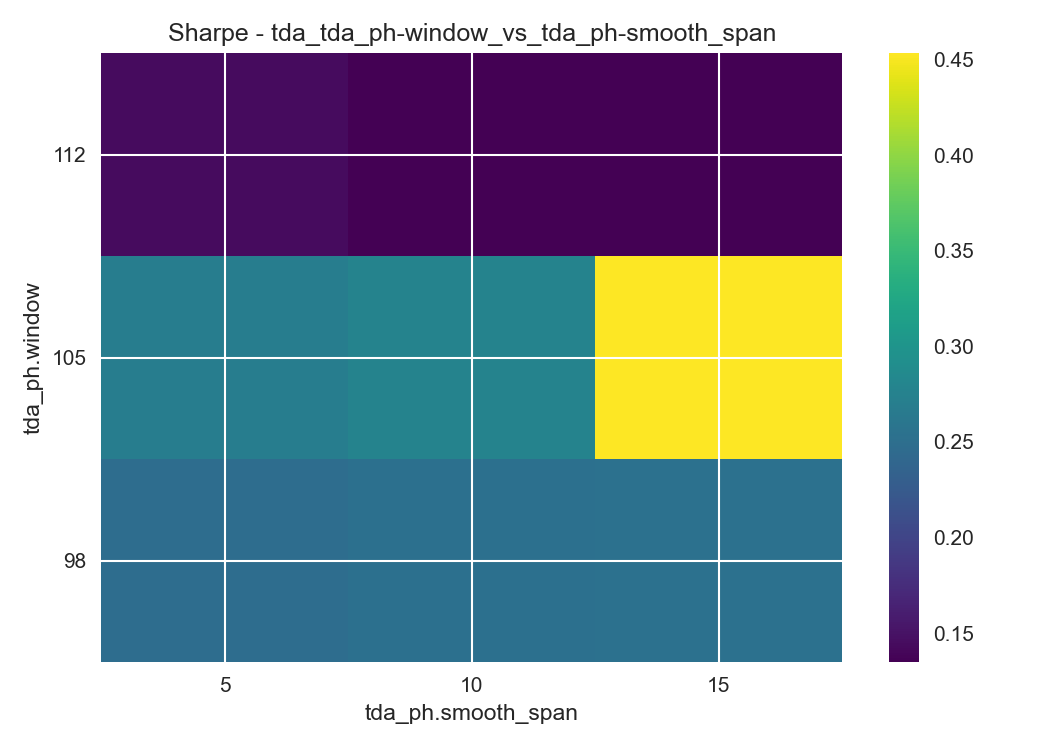

Max_Drawdown heatmap: `d:\GitHub Dic\itau-quant-challenge-2025\reports\parameter_sweeps\tda_tda_ph-window_vs_tda_ph-smooth_span_max_drawdown_heatmap.png`

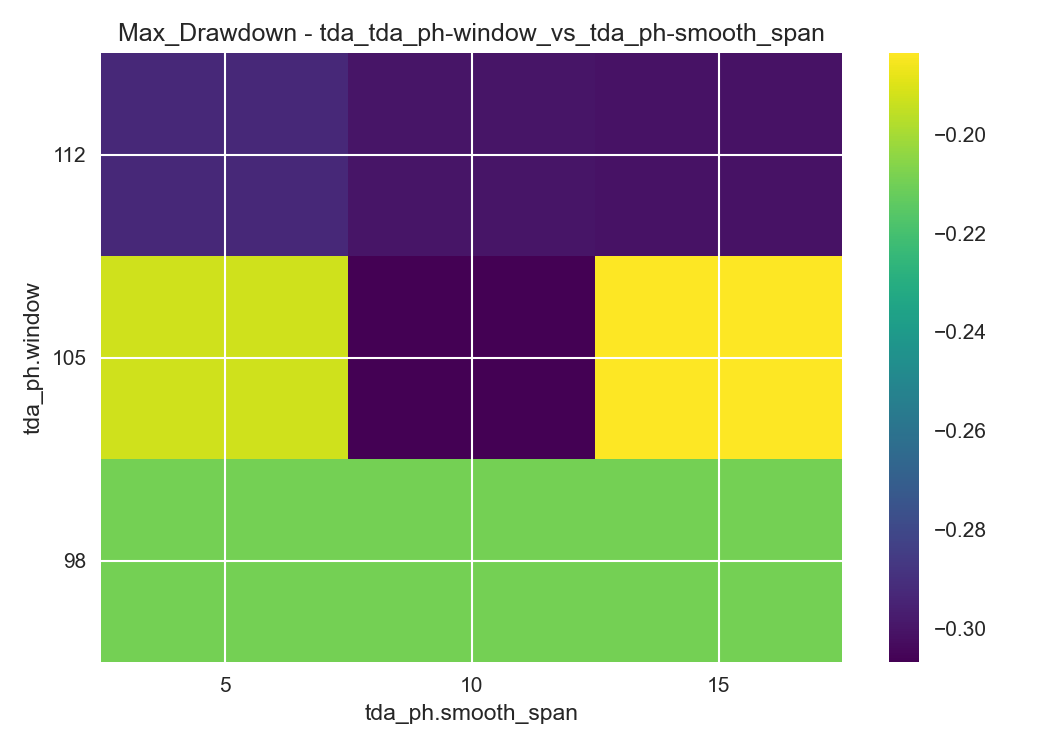

**Grid mapper.n_cubes vs mapper.overlap** - parametros ['mapper.n_cubes', 'mapper.overlap']

 - Backtest tda_mapper-n_cubes_vs_mapper-overlap | mapper.n_cubes=9, mapper.overlap=0.2


Kill switch triggered on 2018-02-14 (vol=0.1647)
Kill switch triggered on 2018-09-04 (vol=0.1616)
Kill switch triggered on 2018-12-28 (vol=0.1666)
Kill switch triggered on 2019-05-21 (vol=0.1630)
Kill switch triggered on 2019-10-24 (vol=0.1603)
Kill switch triggered on 2020-01-02 (vol=0.2225)
Kill switch triggered on 2020-05-04 (vol=0.7606)
Kill switch triggered on 2021-01-04 (vol=0.1734)
Kill switch triggered on 2021-07-12 (vol=0.1622)
Kill switch triggered on 2021-09-02 (vol=0.1845)
Kill switch triggered on 2021-10-01 (vol=0.1609)
Kill switch triggered on 2021-11-16 (vol=0.1631)
Kill switch triggered on 2022-03-07 (vol=0.1606)
Kill switch triggered on 2022-05-02 (mdd=-0.2110,vol=0.3559)
Kill switch triggered on 2022-09-02 (vol=0.1773)
Kill switch triggered on 2023-03-09 (vol=0.1717)
Kill switch triggered on 2023-08-14 (vol=0.1660)
Kill switch triggered on 2023-10-13 (vol=0.1647)
Kill switch triggered on 2023-11-03 (vol=0.1664)
Kill switch triggered on 2023-12-15 (vol=0.1607)
Kill swi

 - Backtest tda_mapper-n_cubes_vs_mapper-overlap | mapper.n_cubes=9, mapper.overlap=0.35


Kill switch triggered on 2018-02-14 (vol=0.1647)
Kill switch triggered on 2018-09-04 (vol=0.1616)
Kill switch triggered on 2018-11-27 (vol=0.1615)
Kill switch triggered on 2019-03-28 (vol=0.1625)
Kill switch triggered on 2019-10-02 (vol=0.1640)
Kill switch triggered on 2020-01-02 (vol=0.2440)
Kill switch triggered on 2020-05-04 (vol=0.7606)
Kill switch triggered on 2021-01-04 (vol=0.1686)
Kill switch triggered on 2021-07-12 (vol=0.1605)
Kill switch triggered on 2021-09-02 (vol=0.1662)
Kill switch triggered on 2021-10-08 (vol=0.1681)
Kill switch triggered on 2021-11-12 (vol=0.1645)
Kill switch triggered on 2022-03-11 (vol=0.1606)
Kill switch triggered on 2022-06-06 (vol=0.1610)
Kill switch triggered on 2022-09-02 (vol=0.2111)
Kill switch triggered on 2023-03-17 (vol=0.1609)
Kill switch triggered on 2023-07-21 (vol=0.1610)
Kill switch triggered on 2023-10-25 (vol=0.1603)
Kill switch triggered on 2024-05-03 (vol=0.1628)
Kill switch triggered on 2024-12-12 (vol=0.1776)
Kill switch triggere

...

 - Backtest tda_mapper-n_cubes_vs_mapper-overlap | mapper.n_cubes=11, mapper.overlap=0.5


Kill switch triggered on 2018-02-14 (vol=0.1647)
Kill switch triggered on 2018-09-03 (vol=0.1647)
Kill switch triggered on 2018-11-27 (vol=0.1691)
Kill switch triggered on 2019-03-27 (vol=0.1613)
Kill switch triggered on 2019-09-02 (vol=0.2111)
Kill switch triggered on 2020-01-10 (vol=0.1600)
Kill switch triggered on 2020-05-04 (vol=0.3235)
Kill switch triggered on 2021-01-04 (vol=0.1731)
Kill switch triggered on 2021-07-07 (vol=0.1609)
Kill switch triggered on 2021-09-02 (vol=0.1685)
Kill switch triggered on 2021-10-04 (vol=0.1634)
Kill switch triggered on 2021-11-12 (vol=0.1706)
Kill switch triggered on 2022-03-15 (vol=0.1607)
Kill switch triggered on 2022-06-06 (vol=0.1619)
Kill switch triggered on 2022-09-02 (vol=0.2124)
Kill switch triggered on 2023-03-09 (vol=0.1606)
Kill switch triggered on 2023-07-27 (vol=0.1615)
Kill switch triggered on 2023-11-03 (vol=0.1781)
Kill switch triggered on 2024-04-30 (vol=0.1602)
Kill switch triggered on 2024-12-11 (vol=0.1604)
Kill switch triggere

Resultados salvos em d:\GitHub Dic\itau-quant-challenge-2025\reports\parameter_sweeps\tda_mapper-n_cubes_vs_mapper-overlap_results.csv


,mapper.n_cubes,mapper.overlap,cagr,sharpe,vol,max_drawdown,calmar
2,9,0.50,0.094884,0.476152,0.199273,-0.192761,0.492238
8,11,0.50,0.069590,0.464091,0.149949,-0.177716,0.391581
1,9,0.35,0.086046,0.435843,0.197425,-0.182739,0.470870
6,11,0.20,0.102639,0.377261,0.272063,-0.216911,0.473184
7,11,0.35,0.066269,0.323292,0.204981,-0.259066,0.255799


Sharpe heatmap: `d:\GitHub Dic\itau-quant-challenge-2025\reports\parameter_sweeps\tda_mapper-n_cubes_vs_mapper-overlap_sharpe_heatmap.png`

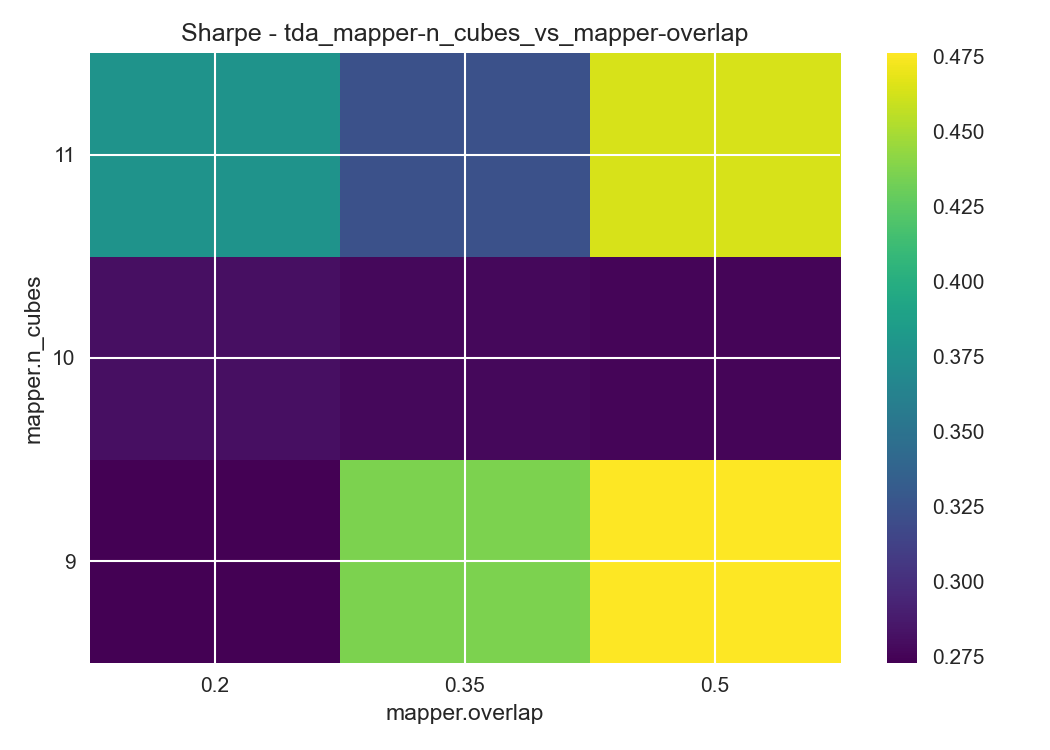

Max_Drawdown heatmap: `d:\GitHub Dic\itau-quant-challenge-2025\reports\parameter_sweeps\tda_mapper-n_cubes_vs_mapper-overlap_max_drawdown_heatmap.png`

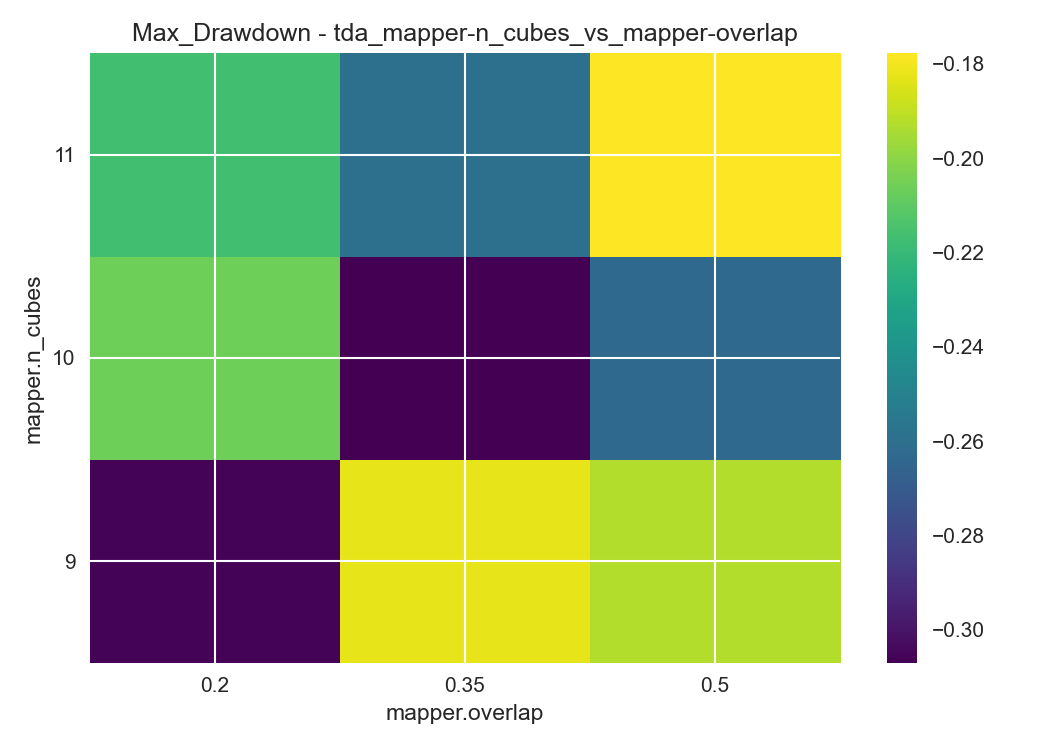

**Grid mapper.overlap vs mapper.eps_quantile** - parametros ['mapper.overlap', 'mapper.eps_quantile']

 - Backtest tda_mapper-overlap_vs_mapper-eps_quantile | mapper.overlap=0.2, mapper.eps_quantile=0.1


Kill switch triggered on 2018-02-14 (vol=0.1647)
Kill switch triggered on 2018-09-03 (vol=0.1660)
Kill switch triggered on 2018-11-06 (vol=0.1601)
Kill switch triggered on 2019-01-15 (vol=0.1609)
Kill switch triggered on 2019-03-27 (vol=0.1673)
Kill switch triggered on 2019-07-01 (vol=0.1606)
Kill switch triggered on 2019-09-02 (vol=0.1660)
Kill switch triggered on 2019-11-22 (vol=0.1632)
Kill switch triggered on 2020-02-20 (vol=0.1663)
Kill switch triggered on 2020-04-01 (vol=0.1949)
Kill switch triggered on 2020-07-08 (vol=0.1689)
Kill switch triggered on 2021-01-04 (vol=0.1896)
Kill switch triggered on 2021-07-08 (vol=0.1615)
Kill switch triggered on 2021-09-02 (vol=0.1769)
Kill switch triggered on 2021-10-04 (vol=0.1713)
Kill switch triggered on 2021-11-11 (vol=0.1644)
Kill switch triggered on 2022-03-15 (vol=0.1601)
Kill switch triggered on 2022-06-06 (vol=0.1630)
Kill switch triggered on 2022-09-02 (vol=0.2040)
Kill switch triggered on 2022-12-23 (vol=0.1737)
Kill switch triggere

 - Backtest tda_mapper-overlap_vs_mapper-eps_quantile | mapper.overlap=0.2, mapper.eps_quantile=0.15


In [ ]:
tda_grids = [
    {"name": "tda_ph.window vs tda_ph.smooth_span", "grid": {"tda_ph.window": [101, 105, 109], "tda_ph.smooth_span": [13, 15, 17]}},
    {"name": "mapper.n_cubes vs mapper.overlap", "grid": {"mapper.n_cubes": [8, 9, 10], "mapper.overlap": [0.4, 0.5, 0.6]}},
    {"name": "mapper.overlap vs mapper.eps_quantile", "grid": {"mapper.overlap": [0.20, 0.35, 0.50], "mapper.eps_quantile": [0.10, 0.15, 0.20]}},
]

tda_runs = {}
for entry in tda_grids:
    name = entry["name"]
    grid = entry["grid"]
    prefix = name.replace(" ", "_").replace(".", "-").replace("/", "-")
    display(Markdown(f"**Grid {name}** - parametros {list(grid.keys())}"))
    results_df, heatmaps = run_two_param_heatmaps(
        cfg,
        panel,
        grid,
        report_prefix=f"tda_{prefix}",
        plot_metrics=("sharpe", "max_drawdown"),
    )
    tda_runs[name] = {"results": results_df, "heatmaps": heatmaps}
    display(results_df.sort_values("sharpe", ascending=False).head())
    for metric, path in heatmaps.items():
        display(Markdown(f"{metric.title()} heatmap: `{path}`"))
        display(Image(filename=str(path), width=420))

tda_summary = pd.DataFrame(
    [
        {"grid": name, "metric": metric, "path": str(path)}
        for name, payload in tda_runs.items()
        for metric, path in payload["heatmaps"].items()
    ]
)
display(Markdown("**Arquivos de heatmap (TDA)**"))
display(tda_summary)


## Kill Switch - Sensibilidade de Parametros
Varre combinacoes relevantes dos limites de drawdown/vol e da janela de monitoramento para verificar impacto em Sharpe e MaxDD.

In [ ]:
kill_switch_grids = {
    "mdd_vs_vol": {
        "risk.mdd_thres": [-0.12, -0.15, -0.18],
        "risk.vol_mult": [1.6, 1.8, 2.0],
    },
    "lookback_vs_cooldown": {
        "risk.mdd_lookback": [45, 60, 90],
        "risk.cooldown_days": [21, 63, 105],
    },
}

kill_switch_runs = {}
for label, grid in kill_switch_grids.items():
    prefix = f"kill_switch_{label}"
    friendly = label.replace("_", " " ).title()
    display(Markdown(f"**Grid {friendly}** - parametros {list(grid.keys())}"))
    results_df, heatmaps = run_two_param_heatmaps(
        cfg,
        panel,
        grid,
        report_prefix=prefix,
        plot_metrics=("sharpe", "max_drawdown")
    )
    kill_switch_runs[label] = {"results": results_df, "heatmaps": heatmaps}
    display(results_df.sort_values("sharpe", ascending=False).head())
    for metric, path in heatmaps.items():
        display(Markdown(f"{metric.title()} heatmap: `{path}`"))
        display(Image(filename=str(path), width=420))

kill_switch_summary = pd.DataFrame(
    [
        {"grid": label, "metric": metric, "path": str(path)}
        for label, payload in kill_switch_runs.items()
        for metric, path in payload["heatmaps"].items()
    ]
)
display(Markdown("**Arquivos de heatmap do kill switch**"))
display(kill_switch_summary)


**Grid Mdd Vs Vol** - parametros ['risk.mdd_thres', 'risk.vol_mult']

 - Backtest kill_switch_mdd_vs_vol | risk.mdd_thres=-0.12, risk.vol_mult=1.6


Kill switch triggered on 2018-02-14 (vol=0.1648)
Kill switch triggered on 2018-09-18 (vol=0.1645)
Kill switch triggered on 2018-11-07 (vol=0.1615)
Kill switch triggered on 2019-01-02 (vol=0.1643)
Kill switch triggered on 2019-03-27 (vol=0.1621)
Kill switch triggered on 2019-06-25 (vol=0.1606)
Kill switch triggered on 2019-09-02 (vol=0.1637)
Kill switch triggered on 2020-01-02 (vol=0.2234)
Kill switch triggered on 2020-05-04 (vol=0.7620)
Kill switch triggered on 2020-10-20 (vol=0.1652)
Kill switch triggered on 2021-02-22 (vol=0.1642)
Kill switch triggered on 2021-06-01 (vol=0.1615)
Kill switch triggered on 2021-09-02 (vol=0.1868)
Kill switch triggered on 2022-02-21 (vol=0.1602)
Kill switch triggered on 2022-05-02 (mdd=-0.1639,vol=0.3325)
Kill switch triggered on 2022-09-02 (vol=0.1792)
Kill switch triggered on 2023-03-01 (mdd=-0.1356)
Kill switch triggered on 2023-07-27 (vol=0.1634)
Kill switch triggered on 2023-11-03 (vol=0.1802)
Kill switch triggered on 2024-04-26 (vol=0.1603)
Kill sw

 - Backtest kill_switch_mdd_vs_vol | risk.mdd_thres=-0.12, risk.vol_mult=1.8


Kill switch triggered on 2018-02-26 (vol=0.1824)
Kill switch triggered on 2018-10-01 (vol=0.1807)
Kill switch triggered on 2018-11-08 (vol=0.1853)
Kill switch triggered on 2018-12-10 (mdd=-0.1206)
Kill switch triggered on 2019-02-05 (mdd=-0.1217)
Kill switch triggered on 2019-06-14 (vol=0.1806)
Kill switch triggered on 2019-09-24 (vol=0.1846)
Kill switch triggered on 2019-11-14 (vol=0.1825)
Kill switch triggered on 2020-01-02 (vol=0.2137)
Kill switch triggered on 2020-05-04 (vol=0.7620)
Kill switch triggered on 2020-10-28 (vol=0.2118)
Kill switch triggered on 2021-05-05 (vol=0.1823)
Kill switch triggered on 2021-09-02 (vol=0.1819)
Kill switch triggered on 2021-11-26 (vol=0.1867)
Kill switch triggered on 2022-03-07 (vol=0.1808)
Kill switch triggered on 2022-05-02 (mdd=-0.2047,vol=0.3274)
Kill switch triggered on 2022-09-05 (vol=0.1806)
Kill switch triggered on 2022-12-13 (mdd=-0.1289)
Kill switch triggered on 2023-05-17 (vol=0.1839)
Kill switch triggered on 2023-09-26 (mdd=-0.1313)
Kill

 - Backtest kill_switch_mdd_vs_vol | risk.mdd_thres=-0.12, risk.vol_mult=2.0


## HRP e Caps - Sensibilidade
Analisa como caps de participacao/cluster e metas de risco influenciam a carteira, facilitando comparacao com as curvas de kill switch.

**Grid Participation Vs Cluster** - parametros ['risk.participation_cap', 'risk.max_cluster_regime.high']

 - Backtest hrp_participation_vs_cluster | risk.participation_cap=0.03, risk.max_cluster_regime.high=0.08


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


 - Backtest hrp_participation_vs_cluster | risk.participation_cap=0.03, risk.max_cluster_regime.high=0.1


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


...

 - Backtest hrp_participation_vs_cluster | risk.participation_cap=0.05, risk.max_cluster_regime.high=0.12


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1309)
Kill switch triggered on 2020-07-13 (vol=0.1372)
Kill switch triggered on 2020-10-01 (vol=0.1435)
Kill switch triggered on 2021-01-07 (vol=0.1300)
Kill switch triggered on 2021-02-22 (vol=0.1540)
Kill switch triggered on 2021-07-12 (vol=0.1294)
Kill switch triggered on 2021-10-04 (vol=0.1409)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


Resultados salvos em c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_participation_vs_cluster_results.csv


,risk.participation_cap,risk.max_cluster_regime.high,cagr,sharpe,vol,max_drawdown,calmar
0,0.03,0.08,0.037834,0.243405,0.155435,-0.221937,0.17047
1,0.03,0.10,0.037834,0.243405,0.155435,-0.221937,0.17047
2,0.03,0.12,0.037834,0.243405,0.155435,-0.221937,0.17047
3,0.04,0.08,0.037834,0.243405,0.155435,-0.221937,0.17047
4,0.04,0.10,0.037834,0.243405,0.155435,-0.221937,0.17047


Sharpe heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_participation_vs_cluster_sharpe_heatmap.png`

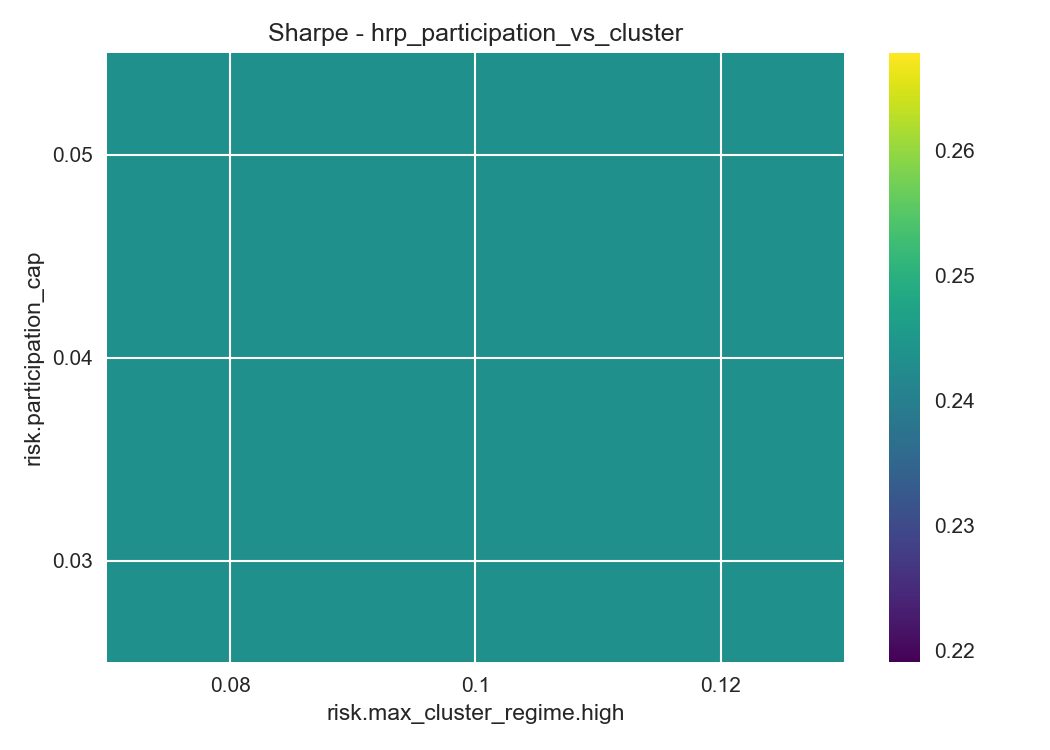

Max_Drawdown heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_participation_vs_cluster_max_drawdown_heatmap.png`

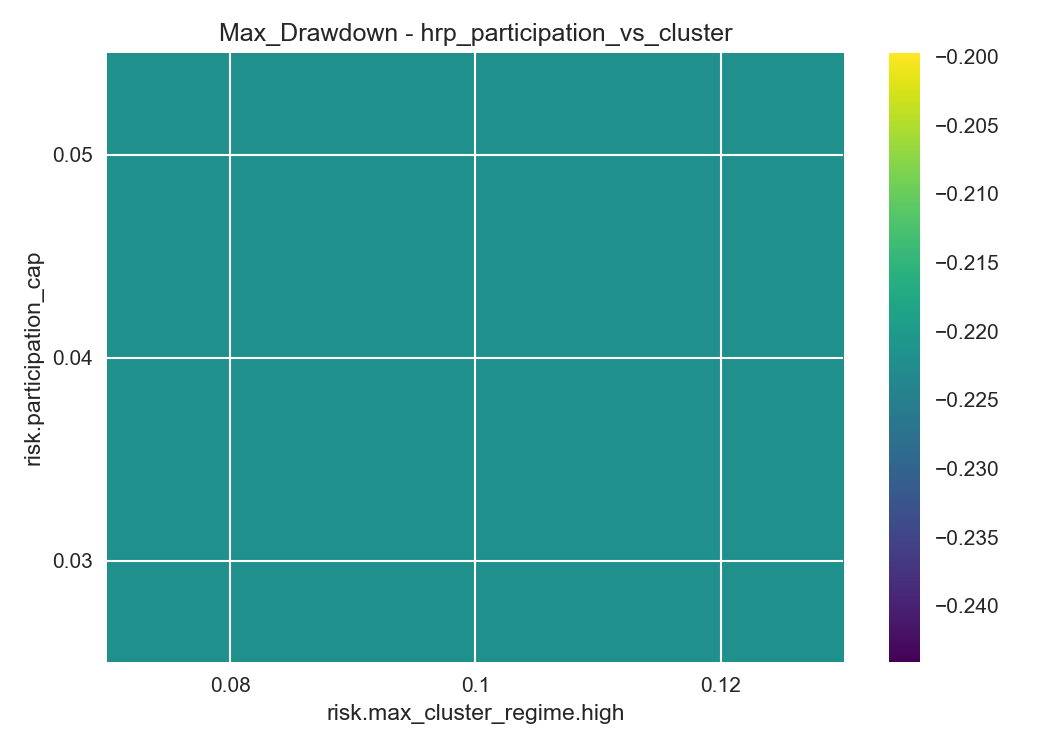

**Grid Target Vol Vs Turnover** - parametros ['risk.target_vol', 'risk.turnover_cap']

 - Backtest hrp_target_vol_vs_turnover | risk.target_vol=0.08, risk.turnover_cap=0.15


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1485)
Kill switch triggered on 2020-07-08 (vol=0.1330)
Kill switch triggered on 2020-10-05 (vol=0.1326)
Kill switch triggered on 2021-01-04 (vol=0.1302)
Kill switch triggered on 2021-02-22 (vol=0.1440)
Kill switch triggered on 2021-07-12 (vol=0.1282)
Kill switch triggered on 2021-10-04 (vol=0.1398)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


 - Backtest hrp_target_vol_vs_turnover | risk.target_vol=0.08, risk.turnover_cap=0.25


Kill switch triggered on 2020-02-12 (vol=0.1303)
Kill switch triggered on 2020-06-01 (vol=0.1485)
Kill switch triggered on 2020-07-08 (vol=0.1330)
Kill switch triggered on 2020-10-05 (vol=0.1326)
Kill switch triggered on 2021-01-04 (vol=0.1302)
Kill switch triggered on 2021-02-22 (vol=0.1440)
Kill switch triggered on 2021-07-12 (vol=0.1289)
Kill switch triggered on 2021-10-04 (vol=0.1404)
Kill switch triggered on 2021-11-16 (vol=0.1348)
Kill switch triggered on 2022-02-09 (vol=0.1300)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3163)
Kill switch triggered on 2022-09-02 (vol=0.1915)


...

 - Backtest hrp_target_vol_vs_turnover | risk.target_vol=0.12, risk.turnover_cap=0.35


Kill switch triggered on 2020-02-26 (vol=0.2399)
Kill switch triggered on 2020-07-31 (vol=0.1956)
Kill switch triggered on 2021-01-29 (vol=0.1972)
Kill switch triggered on 2021-09-02 (mdd=-0.1296,vol=0.1962)
Kill switch triggered on 2021-11-04 (mdd=-0.1273)
Kill switch triggered on 2022-02-17 (vol=0.1926)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3462)
Kill switch triggered on 2022-09-05 (vol=0.1940)


Resultados salvos em c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_target_vol_vs_turnover_results.csv


,risk.target_vol,risk.turnover_cap,cagr,sharpe,vol,max_drawdown,calmar
4,0.10,0.25,0.149359,0.863843,0.172901,-0.207074,0.721286
3,0.10,0.15,0.136518,0.788991,0.173029,-0.228771,0.596745
5,0.10,0.35,0.107652,0.617026,0.174470,-0.272373,0.395239
0,0.08,0.15,0.059979,0.386679,0.155113,-0.221736,0.270497
1,0.08,0.25,0.059913,0.386113,0.155170,-0.221850,0.270061


Sharpe heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_target_vol_vs_turnover_sharpe_heatmap.png`

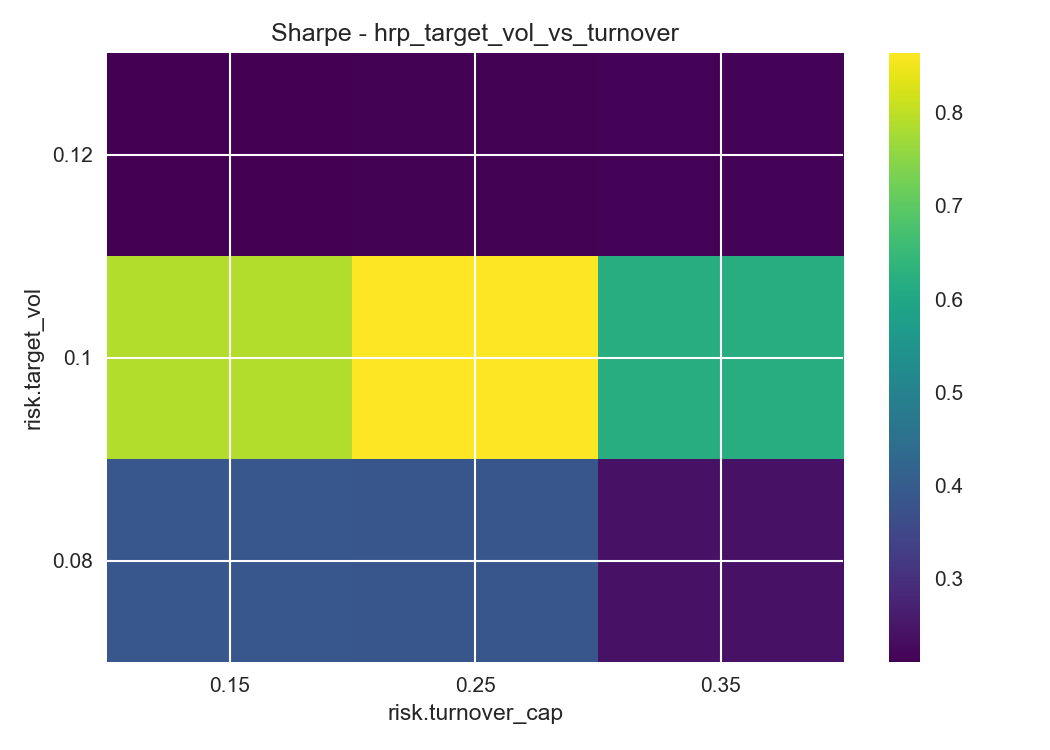

Max_Drawdown heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\hrp_target_vol_vs_turnover_max_drawdown_heatmap.png`

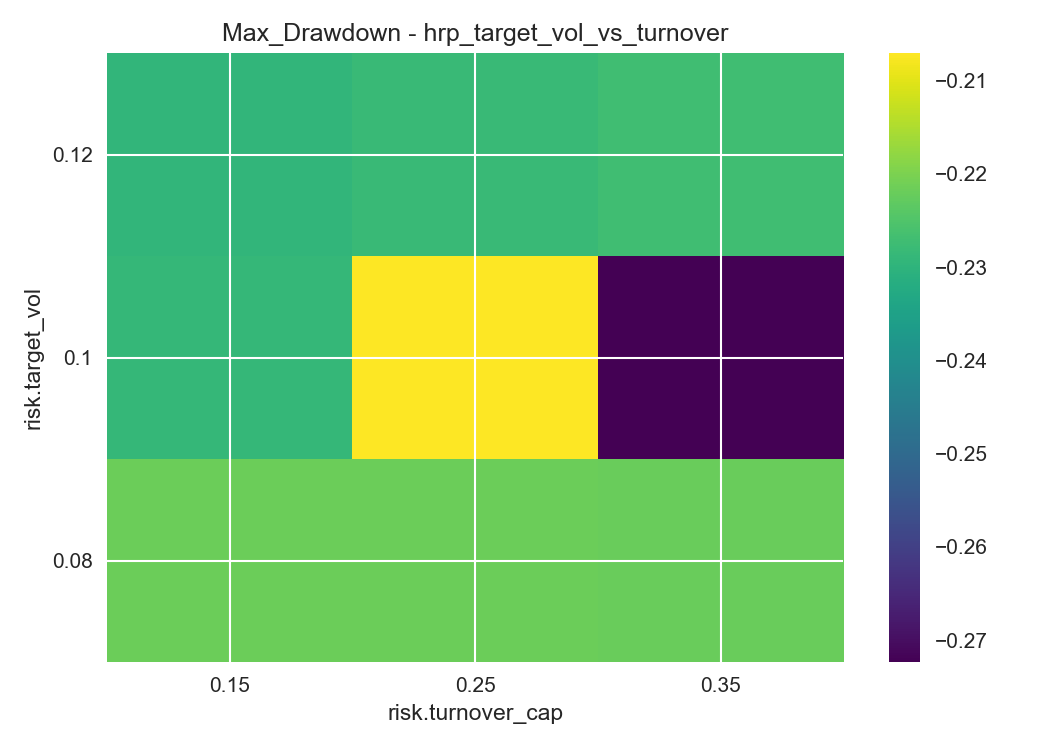

**Arquivos de heatmap (HRP / caps)**

,grid,metric,path
0,participation_vs_cluster,sharpe,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
1,participation_vs_cluster,max_drawdown,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
2,target_vol_vs_turnover,sharpe,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
3,target_vol_vs_turnover,max_drawdown,c:\Users\Cockles\Documents\GitHub\itau-quant-c...


In [ ]:
hrp_grids = {
    "participation_vs_cluster": {
        "risk.participation_cap": [0.03, 0.04, 0.05],
        "risk.max_cluster_regime.high": [0.08, 0.10, 0.12],
    },
    "target_vol_vs_turnover": {
        "risk.target_vol": [0.08, 0.10, 0.12],
        "risk.turnover_cap": [0.15, 0.25, 0.35],
    },
}

hrp_runs = {}
for label, grid in hrp_grids.items():
    prefix = f"hrp_{label}"
    friendly = label.replace("_", " " ).title()
    display(Markdown(f"**Grid {friendly}** - parametros {list(grid.keys())}"))
    results_df, heatmaps = run_two_param_heatmaps(
        cfg,
        panel,
        grid,
        report_prefix=prefix,
        plot_metrics=("sharpe", "max_drawdown")
    )
    hrp_runs[label] = {"results": results_df, "heatmaps": heatmaps}
    display(results_df.sort_values("sharpe", ascending=False).head())
    for metric, path in heatmaps.items():
        display(Markdown(f"{metric.title()} heatmap: `{path}`"))
        display(Image(filename=str(path), width=420))

hrp_summary = pd.DataFrame(
    [
        {"grid": label, "metric": metric, "path": str(path)}
        for label, payload in hrp_runs.items()
        for metric, path in payload["heatmaps"].items()
    ]
)
display(Markdown("**Arquivos de heatmap (HRP / caps)**"))
display(hrp_summary)


## Grid Integrado de Risco
Combina target de volatilidade e limite de drawdown para avaliar consistencia das configuracoes recomendadas.

**Grid integrado** - parametros ['risk.target_vol', 'risk.mdd_thres']

 - Backtest risk_combo | risk.target_vol=0.07, risk.mdd_thres=-0.1


Kill switch triggered on 2020-02-11 (vol=0.1252)
Kill switch triggered on 2020-07-13 (vol=0.1242)
Kill switch triggered on 2021-01-08 (vol=0.1188)
Kill switch triggered on 2021-07-06 (vol=0.1125)
Kill switch triggered on 2021-10-04 (vol=0.1248)
Kill switch triggered on 2021-11-11 (vol=0.1215)
Kill switch triggered on 2022-02-08 (vol=0.1124)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3149)
Kill switch triggered on 2022-09-02 (vol=0.1915)


 - Backtest risk_combo | risk.target_vol=0.07, risk.mdd_thres=-0.12


Kill switch triggered on 2020-02-11 (vol=0.1252)
Kill switch triggered on 2020-07-13 (vol=0.1242)
Kill switch triggered on 2021-01-08 (vol=0.1188)
Kill switch triggered on 2021-07-06 (vol=0.1125)
Kill switch triggered on 2021-10-04 (vol=0.1248)
Kill switch triggered on 2021-11-11 (vol=0.1215)
Kill switch triggered on 2022-02-08 (vol=0.1124)
Kill switch triggered on 2022-05-02 (mdd=-0.1505,vol=0.3149)
Kill switch triggered on 2022-09-02 (vol=0.1915)


...

Resultados salvos em c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\risk_combo_results.csv


,risk.target_vol,risk.mdd_thres,cagr,sharpe,vol,max_drawdown,calmar
6,0.09,-0.10,0.182932,1.306934,0.139970,-0.146688,1.24708
7,0.09,-0.12,0.182932,1.306934,0.139970,-0.146688,1.24708
8,0.09,-0.14,0.182932,1.306934,0.139970,-0.146688,1.24708
3,0.08,-0.10,0.037834,0.243405,0.155435,-0.221937,0.17047
4,0.08,-0.12,0.037834,0.243405,0.155435,-0.221937,0.17047


**Arquivos de heatmap (grid integrado)**

,metric,path
0,sharpe,c:\Users\Cockles\Documents\GitHub\itau-quant-c...
1,max_drawdown,c:\Users\Cockles\Documents\GitHub\itau-quant-c...


Sharpe heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\risk_combo_sharpe_heatmap.png`

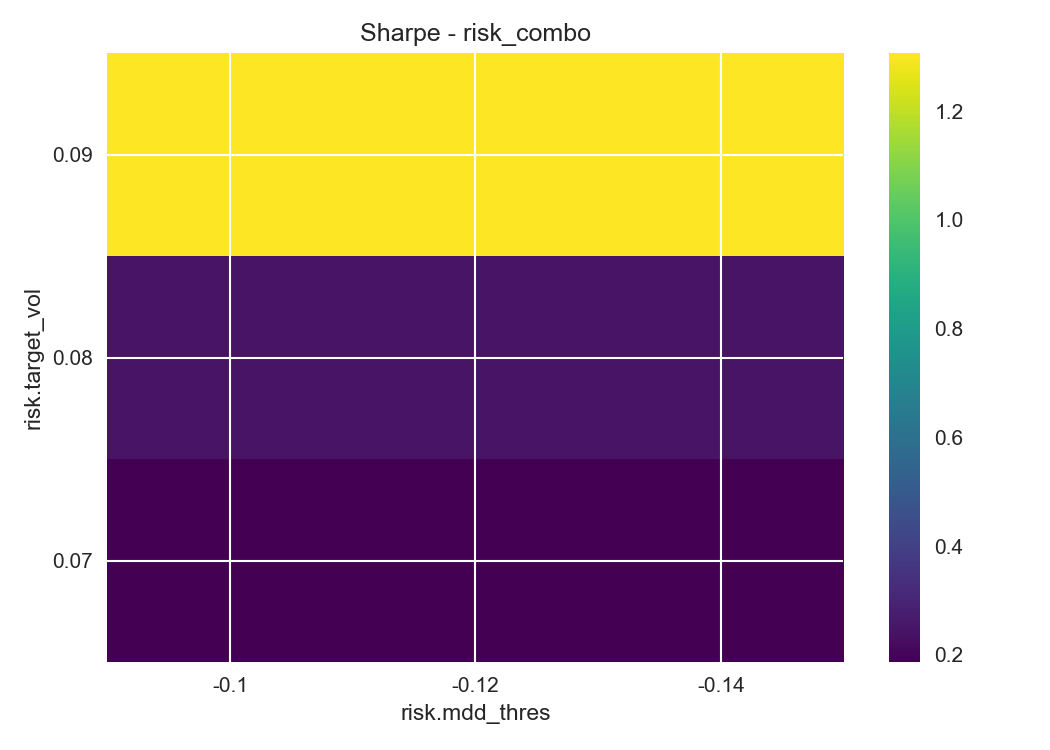

Max_Drawdown heatmap: `c:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\parameter_sweeps\risk_combo_max_drawdown_heatmap.png`

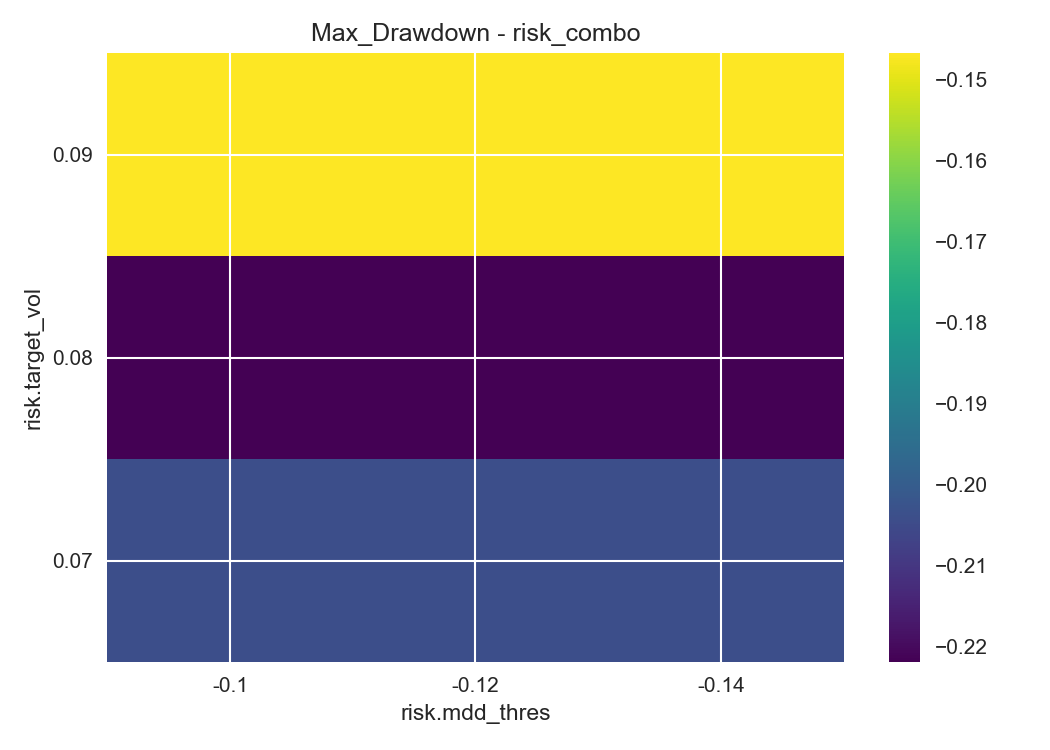

In [ ]:
combined_grid = {
    "risk.target_vol": [0.07, 0.08, 0.09],
    "risk.mdd_thres": [-0.10, -0.12, -0.14],
}

display(Markdown(f"**Grid integrado** - parametros {list(combined_grid.keys())}"))
combined_results, combined_heatmaps = run_two_param_heatmaps(
    cfg,
    panel,
    combined_grid,
    report_prefix="risk_combo",
    plot_metrics=("sharpe", "max_drawdown")
)
display(combined_results.sort_values("sharpe", ascending=False).head())
combined_summary = pd.DataFrame(
    [
        {"metric": metric, "path": str(path)}
        for metric, path in combined_heatmaps.items()
    ]
)
display(Markdown("**Arquivos de heatmap (grid integrado)**"))
display(combined_summary)
for metric, path in combined_heatmaps.items():
    display(Markdown(f"{metric.title()} heatmap: `{path}`"))
    display(Image(filename=str(path), width=420))


## Relatorio PDF (Opcional)
Gera um PDF consolidado com figuras e caminhos dos artefatos.

In [ ]:
# from reports.build_pdf import build_pdf
# 
# pdf_out = REPORTS_DIR / 'consolidated_report.pdf'
# build_pdf(CONFIG_PATH, pdf_out)
# print('PDF salvo em:', pdf_out)

## Proximos Passos
- Ajuste o grid de robustez (ex.: incluir `epsilon`, `n_cubes`, `overlap`).
- Tente diferentes periodos e universos no YAML.
- Compare estrategias alterando `factors.alphas` para diferentes pesos.
